In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv")


data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [67]:
data = data.drop_duplicates().reset_index(drop = True)
data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830
1333,18,female,31.920,0,no,northeast,2205.98080
1334,18,female,36.850,0,no,southeast,1629.83350
1335,21,female,25.800,0,no,southwest,2007.94500


In [68]:
data.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [69]:
data.describe()


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [70]:
data = pd.get_dummies(data)

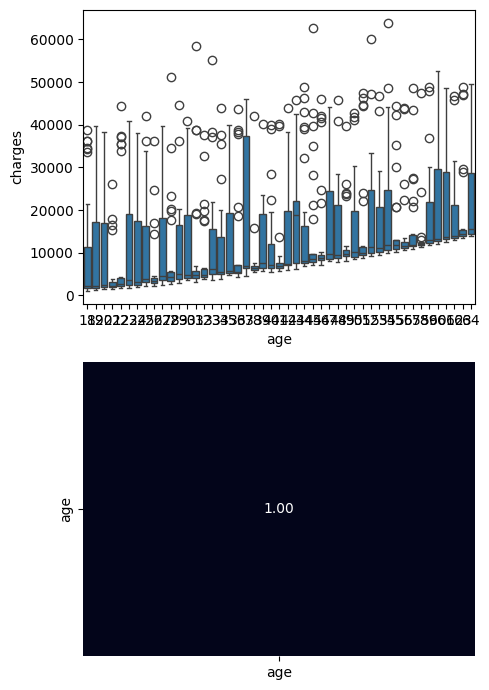

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots with 2 rows and 1 column
fig, axis = plt.subplots(2, 1, figsize=(5, 7))


sns.boxplot(ax=axis[0], data=data, x="age", y="charges")


sns.heatmap(data[["age"]].corr(), annot=True, fmt=".2f", ax=axis[1], cbar=False)


plt.tight_layout()

# Display the plot
plt.show()


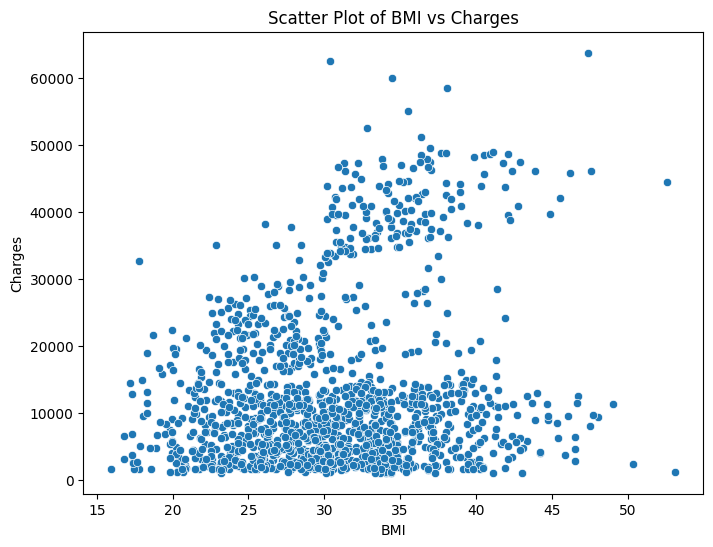

In [72]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', data=data)


plt.title('Scatter Plot of BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.show()

In [74]:
num_var = ["age", "sex" "bmi", "childern", "smoker", "region"]

X = data.drop("charges", axis = 1)
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
1113,23,24.510,0,False,True,True,False,True,False,False,False
967,21,25.745,2,False,True,True,False,True,False,False,False
598,52,37.525,2,True,False,True,False,False,True,False,False
170,63,41.470,0,False,True,True,False,False,False,True,False
275,47,26.600,2,True,False,True,False,True,False,False,False


In [75]:
scaler = MinMaxScaler()

scaler.fit(X_train)


X_train_scal = scaler.transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=X_train.columns)


X_test_scal = scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=X_test.columns)


X_train_scal.head()




,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
1113,0.108696,0.230024,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
967,0.065217,0.263250,0.4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
598,0.739130,0.580172,0.4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
170,0.978261,0.686306,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
275,0.630435,0.286252,0.4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [76]:
X_train = data.drop(["charges"], axis = 1)
y_train = data["charges"]
X_test = data.drop(["charges"], axis = 1)
y_test = data["charges"]

In [77]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [78]:
print(f"Intercep (a): {model.intercept_}")
print(f"Coefficients (b1, b2): {model.coef_}")

Intercep (a): -663.7772041944481
Coefficients (b1, b2): [   256.76461078    339.2503637     474.8204855      64.74073919
    -64.74073919 -11923.6644219   11923.6644219     586.1433797
    236.91684814   -449.12222206   -373.93800577]


In [79]:
y_pred = model.predict(X_test)
y_pred

array([25294.30270323,  3451.76367443,  6707.82797318, ...,
        4151.3157875 ,  1248.07731722, 37086.19413545], shape=(1337,))

In [80]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 36528121.63726907
R2 Score: 0.7507482551410236


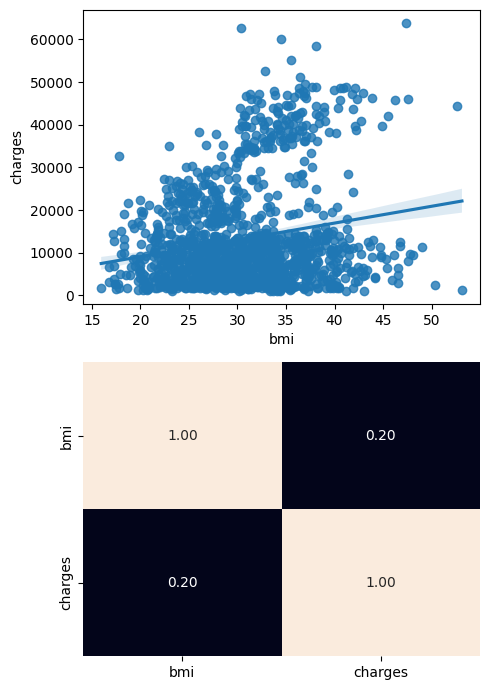

In [86]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))
sns.regplot(ax = axis[0], data = data, x = "bmi", y = "charges")
sns.heatmap(data[["bmi", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()

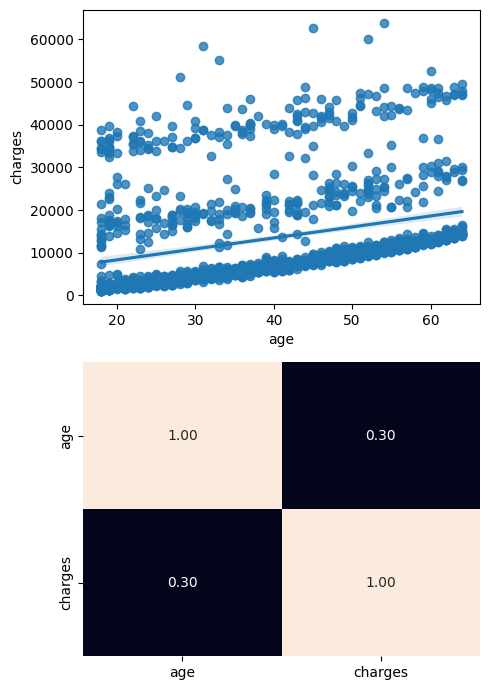

In [87]:
fig, axis = plt.subplots(2, 1, figsize = (5, 7))
sns.regplot(ax = axis[0], data = data, x = "age", y = "charges")
sns.heatmap(data[["age", "charges"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()